## DAG individual neighbourhoods.csv

### 0. Importamos librerías

In [2]:
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

### 1. Carga de datos

In [3]:
# Rutas de los ficheros 
PATH_CSV     = "../data/neighbourhoods.csv"
PATH_GEOJSON = "../data/neighbourhoods.geojson"
PATH_LISTINGS = "../data/listings.csv"

# Carga del CSV de barrios
df_neighbourhoods = pd.read_csv(PATH_CSV)
print(f"neighbourhoods.csv: {df_neighbourhoods.shape[0]} filas, {df_neighbourhoods.shape[1]} columnas")
print(df_neighbourhoods)
print()

# Carga del GeoJSON 
gdf = gpd.read_file(PATH_GEOJSON)
print(f"neighbourhoods.geojson: {len(gdf)} features")
print(gdf[["neighbourhood", "neighbourhood_group", "geometry"]].head(12))
print()

# Carga de listings (para cruzar barrios) 
df_listings = pd.read_csv(PATH_LISTINGS)

print(f"listings.csv: {df_listings.shape[0]} filas cargadas.")
print(df_listings["neighbourhood_cleansed"].value_counts())
print()

neighbourhoods.csv: 11 filas, 2 columnas
    neighbourhood_group         neighbourhood
0                   NaN     Bailen-Miraflores
1                   NaN           Campanillas
2                   NaN    Carretera de Cadiz
3                   NaN                Centro
4                   NaN             Churriana
5                   NaN         Ciudad Jardin
6                   NaN   Cruz De Humilladero
7                   NaN                  Este
8                   NaN        Palma-Palmilla
9                   NaN    Puerto de la Torre
10                  NaN  Teatinos-Universidad

neighbourhoods.geojson: 11 features
           neighbourhood neighbourhood_group  \
0              Churriana                None   
1     Carretera de Cadiz                None   
2   Teatinos-Universidad                None   
3         Palma-Palmilla                None   
4          Ciudad Jardin                None   
5                   Este                None   
6                 Centro          

In [4]:
df_listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,96033,https://www.airbnb.com/rooms/96033,20250930030808,2025-09-30,city scrape,"Bonito piso a 200m de la playa, El Palo (Málaga)",Do you have a backpacker spirit and are lookin...,"200 metres from the beaches of El Palo, Malaga...",https://a0.muscache.com/pictures/hosting/Hosti...,510467,...,4.93,4.44,4.61,ESFCTU0000290200003588210000000000000000VUT/MA...,f,1,1,0,0,1.88
1,166473,https://www.airbnb.com/rooms/166473,20250930030808,2025-09-30,city scrape,Perfect Location In Malaga,This apartment is rented out by the room - new...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,793360,...,4.91,4.80,4.72,NaN,f,5,1,4,0,0.59
2,330760,https://www.airbnb.com/rooms/330760,20250930030808,2025-09-30,city scrape,Malaga Lodge Guesthouse Double room-shared bath.,The Lodge is set in a charming town house in L...,Málaga Lodge is situated next to the famous Sa...,https://a0.muscache.com/pictures/85419390/38a9...,1687526,...,4.62,4.52,4.48,ESHFTU0000290200004234200060000000000000VFT/MA...,t,6,4,2,0,0.41
3,340024,https://www.airbnb.com/rooms/340024,20250930030808,2025-09-30,city scrape,NEW APARTMENT IN MALAGA CENTER,Welcome to Málaga!<br />This is a modern and e...,It is a central area and has all kinds of serv...,https://a0.muscache.com/pictures/hosting/Hosti...,1725690,...,4.79,4.72,4.77,VFT/MA/02334,f,1,1,0,0,2.11
4,358541,https://www.airbnb.com/rooms/358541,20250930030808,2025-09-30,city scrape,Casa La Maga - Apartment for happy people,"For years, Raúl and I were super happy in this...",The apartment is in the very heart of Malaga C...,https://a0.muscache.com/pictures/miso/Hosting-...,1526932,...,4.97,4.80,4.78,VFT/MA/02288,f,1,1,0,0,2.48


### 2. Exploración inicial

In [5]:
# Tipos de datos y nulos en neighbourhoods.csv 
print("- Tipos de datos")
print(df_neighbourhoods.dtypes)
print()
print("- Valores nulos por columna")
print(df_neighbourhoods.isnull().sum())
print()
print("- Valores únicos por columna")
for col in df_neighbourhoods.columns:
    print(f"  {col}: {df_neighbourhoods[col].nunique()} únicos → {df_neighbourhoods[col].unique()}")

- Tipos de datos
neighbourhood_group    float64
neighbourhood              str
dtype: object

- Valores nulos por columna
neighbourhood_group    11
neighbourhood           0
dtype: int64

- Valores únicos por columna
  neighbourhood_group: 0 únicos → [nan]
  neighbourhood: 11 únicos → <StringArray>
[   'Bailen-Miraflores',          'Campanillas',   'Carretera de Cadiz',
               'Centro',            'Churriana',        'Ciudad Jardin',
  'Cruz De Humilladero',                 'Este',       'Palma-Palmilla',
   'Puerto de la Torre', 'Teatinos-Universidad']
Length: 11, dtype: str


In [6]:
# Exploración del GeoJSON 
print("- Nulos en GeoJSON")
print(gdf[["neighbourhood", "neighbourhood_group"]].isnull().sum())

- Nulos en GeoJSON
neighbourhood           0
neighbourhood_group    11
dtype: int64


### 3- Limpieza y validación

In [7]:
# 3.2 Verificar que los barrios del CSV y el GeoJSON coinciden 
barrios_csv = set(df_neighbourhoods["neighbourhood"])
barrios_geo = set(gdf["neighbourhood"])

solo_en_csv = barrios_csv - barrios_geo
solo_en_geo = barrios_geo - barrios_csv

if not solo_en_csv and not solo_en_geo:
    print("[CORRECTO] CSV y GeoJSON tienen exactamente los mismos 11 barrios.")
else:
    print(f"[AVISO] Solo en CSV: {solo_en_csv}")
    print(f"[AVISO] Solo en GeoJSON: {solo_en_geo}")

[CORRECTO] CSV y GeoJSON tienen exactamente los mismos 11 barrios.


In [8]:
# 3.3 Verificar que los barrios de listings coinciden con los conocidos 
barrios_listings = set(df_listings["neighbourhood_cleansed"].dropna().unique())
barrios_conocidos = barrios_csv

desconocidos = barrios_listings - barrios_conocidos
print(f"Barrios en listings no presentes en neighbourhoods.csv: {desconocidos}")

# Listings sin barrio asignado (NaN)
nulos_barrio = df_listings["neighbourhood_cleansed"].isnull().sum()
print(f"Listings sin barrio (NaN): {nulos_barrio}")

print(df_listings["neighbourhood_cleansed"])

Barrios en listings no presentes en neighbourhoods.csv: set()
Listings sin barrio (NaN): 0
0                      Este
1                      Este
2                    Centro
3                    Centro
4                    Centro
               ...         
9709    Cruz De Humilladero
9710                 Centro
9711                   Este
9712                 Centro
9713                   Este
Name: neighbourhood_cleansed, Length: 9714, dtype: str


### 4. Transformación de Datos

In [9]:
# 4.1 Definir agrupación geográfica de barrios 
# Basada en proximidad geográfica dentro de Málaga
GRUPOS_BARRIOS = {
    "Centro"   : ["Centro"],
    "Este"     : ["Este"],
    "Oeste"    : ["Carretera de Cadiz", "Cruz De Humilladero", "Teatinos-Universidad", "Churriana", "Campanillas", "Puerto de la Torre"],
    "Norte"    : ["Bailen-Miraflores", "Palma-Palmilla", "Ciudad Jardin"],
}

# Construir mapa inverso: {barrio: grupo}
mapa_barrio_grupo = {
    barrio: grupo
    for grupo, barrios in GRUPOS_BARRIOS.items()
    for barrio in barrios
}

print("Mapa barrio -> grupo:")
for k, v in mapa_barrio_grupo.items():
    print(f"  {k:30s} -> {v}")

Mapa barrio -> grupo:
  Centro                         -> Centro
  Este                           -> Este
  Carretera de Cadiz             -> Oeste
  Cruz De Humilladero            -> Oeste
  Teatinos-Universidad           -> Oeste
  Churriana                      -> Oeste
  Campanillas                    -> Oeste
  Puerto de la Torre             -> Oeste
  Bailen-Miraflores              -> Norte
  Palma-Palmilla                 -> Norte
  Ciudad Jardin                  -> Norte


In [10]:
# 4.2 Asignar neighbourhood_group al CSV y al GeoJSON 
df_neighbourhoods["neighbourhood_group"] = (
    df_neighbourhoods["neighbourhood"].map(mapa_barrio_grupo)
)

gdf["neighbourhood_group"] = (
    gdf["neighbourhood"].map(mapa_barrio_grupo)
)

print(df_neighbourhoods)

   neighbourhood_group         neighbourhood
0                Norte     Bailen-Miraflores
1                Oeste           Campanillas
2                Oeste    Carretera de Cadiz
3               Centro                Centro
4                Oeste             Churriana
5                Norte         Ciudad Jardin
6                Oeste   Cruz De Humilladero
7                 Este                  Este
8                Norte        Palma-Palmilla
9                Oeste    Puerto de la Torre
10               Oeste  Teatinos-Universidad


### 5. Enriquecimiento de Datos 

In [ ]:
# 1. Limpiar precios de listings
df_listings['price'] = df_listings['price'].replace(r'[\$,]', '', regex=True).astype(float)

# 2. Resumen (Agg)
stats_barrios = df_listings.groupby('neighbourhood_cleansed').agg(
    num_anuncios=('id', 'count'),
    precio_medio=('price', 'mean'),
    disponibilidad_media=('availability_365', 'mean'),
    reviews_totales=('number_of_reviews', 'sum')
).reset_index()

# Limpieza de espacios para que el merge no falle
df_neighbourhoods['neighbourhood'] = df_neighbourhoods['neighbourhood'].str.strip()
gdf['neighbourhood'] = gdf['neighbourhood'].str.strip()
stats_barrios['neighbourhood_cleansed'] = stats_barrios['neighbourhood_cleansed'].str.strip()

# 3. MERGE para el DataFrame normal
df_neighbourhoods = df_neighbourhoods.merge(stats_barrios, left_on='neighbourhood', right_on='neighbourhood_cleansed', how='left')
if 'neighbourhood_cleansed' in df_neighbourhoods.columns:
    df_neighbourhoods = df_neighbourhoods.drop(columns=['neighbourhood_cleansed'])
df_neighbourhoods = df_neighbourhoods.fillna(0)

# 4. MERGE para el GeoDataFrame
gdf = gdf.merge(stats_barrios, left_on='neighbourhood', right_on='neighbourhood_cleansed', how='left')
if 'neighbourhood_cleansed' in gdf.columns:
    gdf = gdf.drop(columns=['neighbourhood_cleansed'])
gdf = gdf.fillna(0)

# 5. REORDENAR columnas en ambos para que neighbourhood sea la primera
columnas_orden = ['neighbourhood', 'neighbourhood_group', 'num_anuncios', 'precio_medio', 'disponibilidad_media', 'reviews_totales']

# En el gdf hay que mantener la columna 'geometry', si no te quedas sin mapa
df_neighbourhoods = df_neighbourhoods[columnas_orden]
gdf = gdf[columnas_orden + ['geometry']] 

df_neighbourhoods.head()

,neighbourhood,neighbourhood_group,num_anuncios,precio_medio,disponibilidad_media,reviews_totales
0,Bailen-Miraflores,Norte,312,540.588028,203.057692,15814
1,Campanillas,Oeste,33,2762.935484,245.333333,887
2,Carretera de Cadiz,Oeste,935,298.492468,194.533690,43528
3,Centro,Centro,6389,215.445184,210.782752,357655
4,Churriana,Oeste,150,695.780142,210.826667,5382


### 6. Visualización de Datos

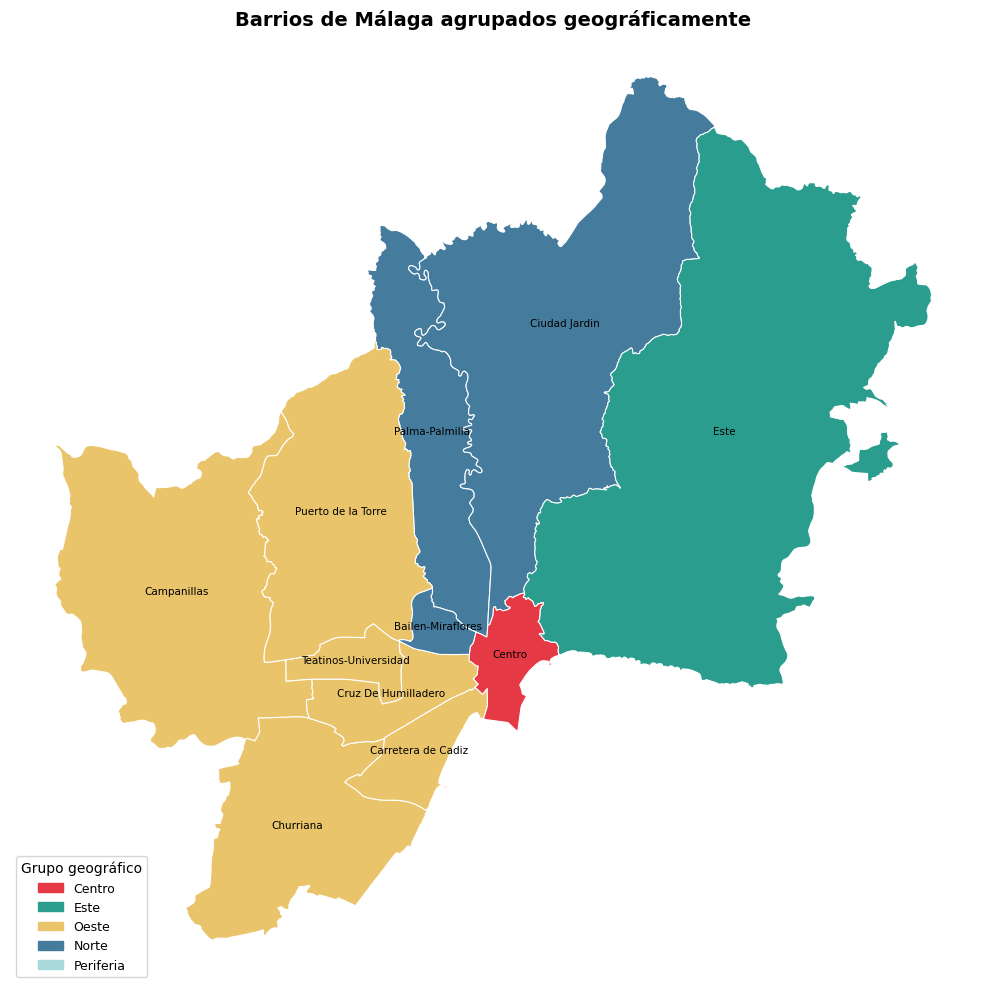

In [18]:
# 5.1 Mapa de barrios coloreado por grupo geográfico 
COLORES_GRUPOS = {
    "Centro"   : "#e63946",
    "Este"     : "#2a9d8f",
    "Oeste"    : "#e9c46a",
    "Norte"    : "#457b9d",
    "Periferia": "#a8dadc",
}

gdf["color"] = gdf["neighbourhood_group"].map(COLORES_GRUPOS)

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color=gdf["color"], edgecolor="white", linewidth=0.8)

# Etiquetas con el nombre de cada barrio
for _, row in gdf.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=row["neighbourhood"],
        xy=(centroid.x, centroid.y),
        fontsize=7.5,
        ha="center",
        color="black"
    )

# Leyenda por grupo
leyenda = [
    mpatches.Patch(color=color, label=grupo)
    for grupo, color in COLORES_GRUPOS.items()
]
ax.legend(handles=leyenda, title="Grupo geográfico", loc="lower left", fontsize=9)

ax.set_title("Barrios de Málaga agrupados geográficamente", fontsize=14, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

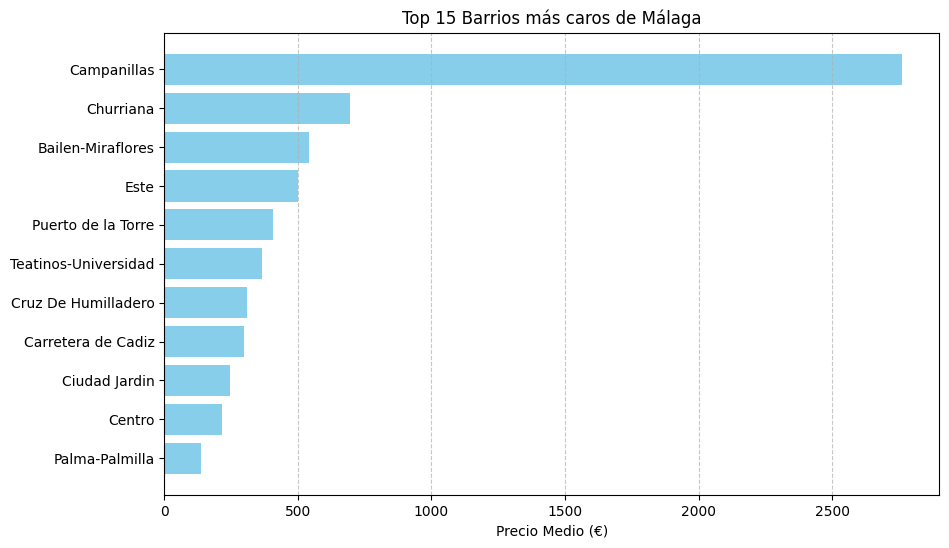

In [17]:
# Ordenamos para mostrar los 15 barrios más caros
top_precios = df_neighbourhoods.sort_values('precio_medio', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_precios['neighbourhood'], top_precios['precio_medio'], color='skyblue')
plt.xlabel('Precio Medio (€)')
plt.title('Top 15 Barrios más caros de Málaga')
plt.gca().invert_yaxis()  # Para que el más caro salga arriba
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

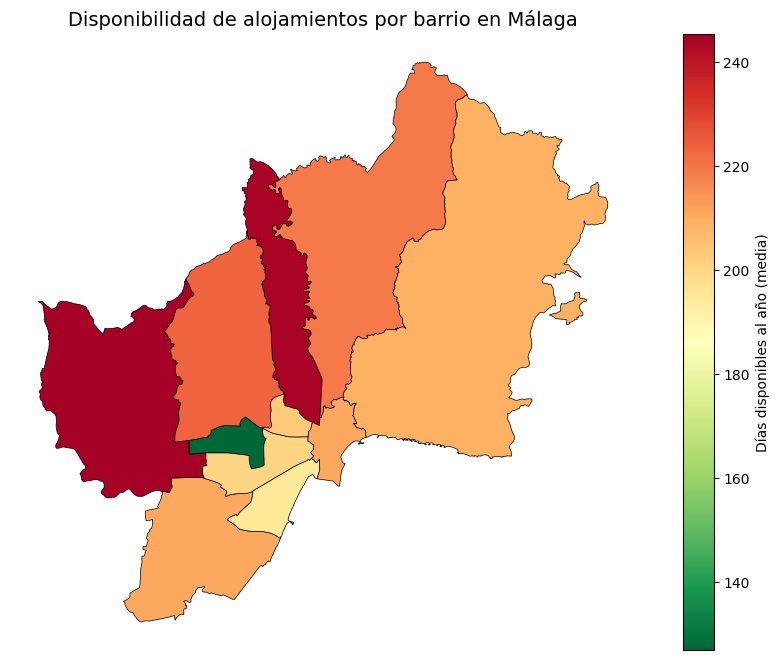

In [19]:
fig, ax = plt.subplots(figsize=(12, 8))

# Usamos la nueva variable 'disponibilidad_media'
gdf.plot(column='disponibilidad_media', 
         cmap='RdYlGn_r', # Verde (poca disponibilidad) a Rojo (mucha)
         legend=True,
         legend_kwds={'label': "Días disponibles al año (media)", 'orientation': "vertical"},
         edgecolor='black', 
         linewidth=0.5, 
         ax=ax)

ax.set_title('Disponibilidad de alojamientos por barrio en Málaga', fontsize=14)
ax.set_axis_off()
plt.show()

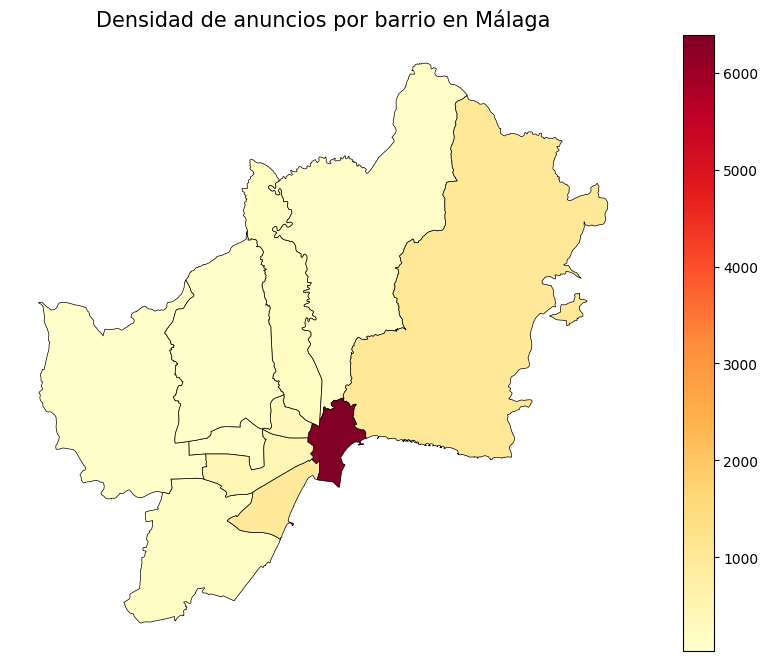

In [20]:
fig, ax = plt.subplots(figsize=(12, 8))

# Dibujamos el mapa usando la columna 'num_anuncios' para el color
gdf.plot(column='num_anuncios', 
         cmap='YlOrRd', 
         legend=True, 
         edgecolor='black', 
         linewidth=0.5, 
         ax=ax)

ax.set_title('Densidad de anuncios por barrio en Málaga', fontsize=15)
ax.set_axis_off()
plt.show()

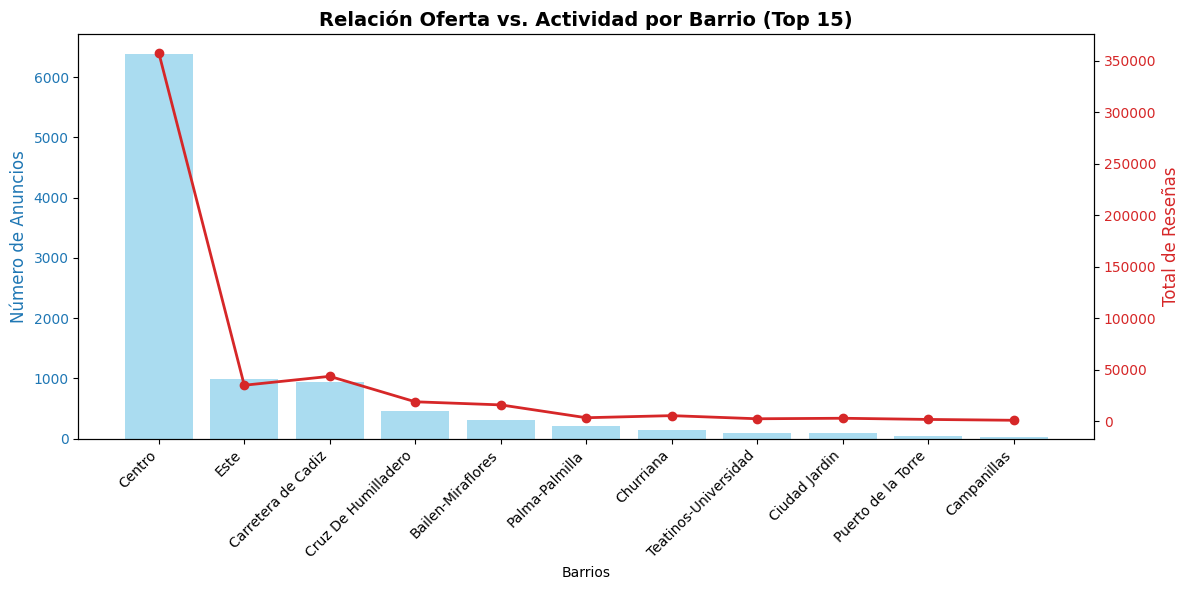

In [21]:
# Ordenamos por número de anuncios para que el gráfico sea legible
df_sorted = df_neighbourhoods.sort_values('num_anuncios', ascending=False).head(15)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje 1: Barras para la Oferta (Número de anuncios)
color_anuncios = 'skyblue'
ax1.set_xlabel('Barrios')
ax1.set_ylabel('Número de Anuncios', color='tab:blue', fontsize=12)
bars = ax1.bar(df_sorted['neighbourhood'], df_sorted['num_anuncios'], color=color_anuncios, alpha=0.7, label='Oferta (Anuncios)')
ax1.tick_params(axis='y', labelcolor='tab:blue')
plt.xticks(rotation=45, ha='right')

# Eje 2: Línea para la Actividad (Total de Reseñas)
ax2 = ax1.twinx()  # Creamos el segundo eje y
color_reviews = 'tab:red'
ax2.set_ylabel('Total de Reseñas', color=color_reviews, fontsize=12)
ax2.plot(df_sorted['neighbourhood'], df_sorted['reviews_totales'], color=color_reviews, marker='o', linewidth=2, label='Actividad (Reseñas)')
ax2.tick_params(axis='y', labelcolor=color_reviews)

# Título y ajustes
plt.title('Relación Oferta vs. Actividad por Barrio (Top 15)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

Los barrios con más reseñas son los que más anuncios tienen como debería ser lo normal